# Analisis de sentimientos en reseñas de Trip Advisor

**DIEGO BESADA RODRÍGUEZ**

<div>
  <img src="images/tripadvisor.svg"
       alt="Logo Tripadvisor"
       width="400">
</div>

<br>

<div style="border:2px solid lightgreen; padding:10px; border-radius:5px; background-color:#ECFEEA;">
<strong>Estado:</strong> Terminado.
</div>

<br>

<div style="border:2px solid orange; padding:10px; border-radius:5px; background-color:#fff3cd;">
<strong>⚠️ Warning:</strong> Este notebook requiere numpy &lt; 2.0 para que fastText funcione.
</div>

In [ ]:
import nltk
import numpy as np
import pandas as pd
import string
from tqdm.auto import tqdm
from collections import Counter

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.utils import resample
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score, confusion_matrix
from sklearn.cluster import KMeans
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer, StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

from gensim.models import Word2Vec

tqdm.pandas()

In [2]:
# Descargar recursos de NLTK (solo la primera vez)

# nltk.download('punkt')
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('punkt_tab')
# nltk.download('words')

In [3]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords, words
from nltk.stem import PorterStemmer, WordNetLemmatizer

from spellchecker import SpellChecker

### PREPROCESADO:

In [4]:
df = pd.read_csv('Datasets/tripadvisor_hotel_reviews.csv')
df.head()

,Review,Rating
0,nice hotel expensive parking got good deal sta...,4
1,ok nothing special charge diamond member hilto...,2
2,nice rooms not 4* experience hotel monaco seat...,3
3,"unique, great stay, wonderful time hotel monac...",5
4,"great stay great stay, went seahawk game aweso...",5


Podemos ver un dataset con una estructura muy sencilla: dos columnas, en una la reseña y en la otra el rating. A continuación comprobaremos si todas las reseñas son en inglés. Para ello, se probó con la libreria langdetect, que arroja 20 resultados de reseñas en lengua no inglesa. Sin embargo, si estos son revisados, se puede comprobar que la mayoria en realidad si que son escritos en inglés. Se va a probar a usar fasttext, librería desarrollada por meta. Es necesario instalar tanto la libreria como el modelo (y asegurar numpy<2.0), que puede encontrase en: https://fasttext.cc/docs/en/language-identification.html. La siguiente celda de código descarga de manera directa este modelo y lo guarda en la carpeta utilities.

In [5]:
# ! curl https://dl.fbaipublicfiles.com/fasttext/supervised-models/lid.176.bin -o utilities/lid.176.bin

In [6]:
import fasttext

model = fasttext.load_model("utilities/lid.176.bin")

def is_english(text):
    try:
        text = str(text).replace("\n", " ").strip()
        if len(text) == 0:
            return False
        
        labels, probs = model.predict(text)
        return labels[0] == '__label__en'
    except:
        return False
            
df['is_english'] = df['Review'].progress_apply(is_english)

  0%|          | 0/20491 [00:00<?, ?it/s]

In [7]:
for index, row in df[~df['is_english']].iterrows():
    print(str(index) + ':', row['Review'])

12932: great, sorry french-speaking girl english n't really good, went sirenie tropical suites beinnig septembre 2004 yep hurricanes n't worry weather great time, enjoyed trip dominican republic hotel beautiful place return anytime, tout m'a pl__ dans cet h___tel c'est rÄellement incroyable, j en garde merveilleux souvenirs,  
14397: sparkle ritz carlton chandeliers potzdamer platz view room 1032. old esplanade adapts urban chic potsdamer platz,  
17264: une trappe touristes 4* ne pas approcher des boutiques sur la plage vous ne pourrez pas ressortir sans avoir achetÄ,  
18859: hotel unique moment inoubliable lieu hors du temps une vegetation magnifique et des bungalows intimes et ravissants,  
19840: best value london, bit far central london amazing hotel hoxton weeks job happy vraiment hotel fantastique et prix gÄnial,  


In [8]:
df = df[df['is_english']].copy()[['Review', 'Rating']]

In [9]:
# # Prueba anterior con langdetect (no es tan precisa y es más lenta)

# from langdetect import detect
# from tqdm.auto import tqdm

# def is_english(text):
#     try:
#         return detect(text) == 'en'
#     except:
#         return False

# df['is_english'] = df['Review'].progress_apply(is_english)

Ahora, podemos pasar a preprocesar los textos:

In [10]:
stop_words = set(stopwords.words('english'))
stemmer = PorterStemmer()
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    # 1. Tokenizar
    tokens = word_tokenize(text)
    
    # 2. Minúsculas
    tokens = [word.lower() for word in tokens]
    
    # 3. Eliminar puntuación
    tokens = [word for word in tokens if word not in string.punctuation]
    
    # 4. Solo palabras alfabéticas
    tokens = [word for word in tokens if word.isalpha()]
    
    # 5. Eliminar stopwords
    tokens = [word for word in tokens if word not in stop_words]
    
    # 6. Stemming
    stemmed = [stemmer.stem(word) for word in tokens]
    
    # 7. Lemmatization
    lemmatized = [lemmatizer.lemmatize(word) for word in tokens]
    
    return {
        "tokens": tokens,
        "stemmed": stemmed,
        "lemmatized": lemmatized
    }

In [11]:
df['processed'] = df['Review'].progress_apply(preprocess)

df['Tokens'] = df['processed'].apply(lambda x: x['tokens'])
df['Stemmed'] = df['processed'].apply(lambda x: x['stemmed'])
df['Lemmatized'] = df['processed'].apply(lambda x: x['lemmatized'])

df = df[['Review', 'Rating', 'Tokens', 'Stemmed', 'Lemmatized']]

  0%|          | 0/20486 [00:00<?, ?it/s]

In [12]:
df.head()

,Review,Rating,Tokens,Stemmed,Lemmatized
0,nice hotel expensive parking got good deal sta...,4,"[nice, hotel, expensive, parking, got, good, d...","[nice, hotel, expens, park, got, good, deal, s...","[nice, hotel, expensive, parking, got, good, d..."
1,ok nothing special charge diamond member hilto...,2,"[ok, nothing, special, charge, diamond, member...","[ok, noth, special, charg, diamond, member, hi...","[ok, nothing, special, charge, diamond, member..."
2,nice rooms not 4* experience hotel monaco seat...,3,"[nice, rooms, experience, hotel, monaco, seatt...","[nice, room, experi, hotel, monaco, seattl, go...","[nice, room, experience, hotel, monaco, seattl..."
3,"unique, great stay, wonderful time hotel monac...",5,"[unique, great, stay, wonderful, time, hotel, ...","[uniqu, great, stay, wonder, time, hotel, mona...","[unique, great, stay, wonderful, time, hotel, ..."
4,"great stay great stay, went seahawk game aweso...",5,"[great, stay, great, stay, went, seahawk, game...","[great, stay, great, stay, went, seahawk, game...","[great, stay, great, stay, went, seahawk, game..."


### **ANÁLISIS DEL TEXTO:**

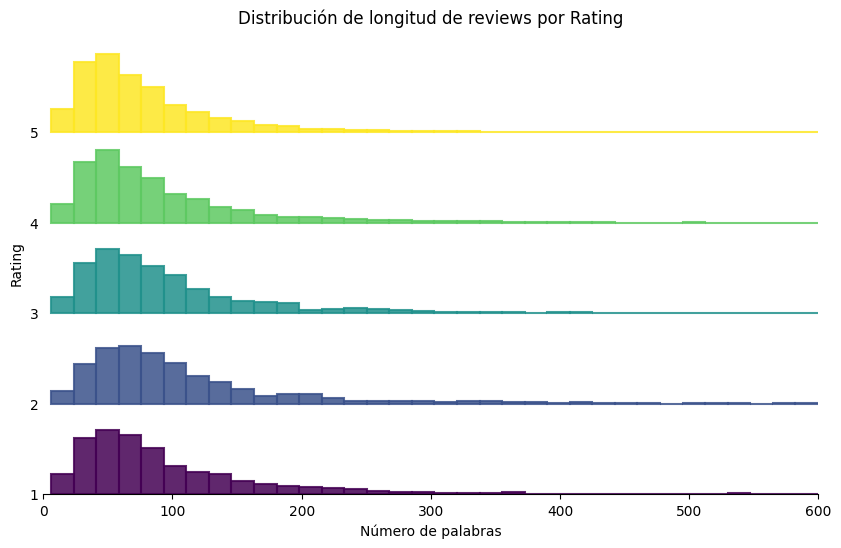

In [13]:
from utilities.graphs import joyplot

df['Length'] = df['Tokens'].apply(len)

fig, ax = plt.subplots(figsize=(10, 6))

joyplot(
    ax=ax,
    data=df.sort_values('Rating'),
    group_col="Rating",
    value_col="Length",
    offset=1.1,
    bins=100,
    scale=0.95,
    cmap="viridis"
)

ax.set_xlim(0, 600)
ax.set_title("Distribución de longitud de reviews por Rating")
ax.set_xlabel("Número de palabras")
ax.set_ylabel("Rating")
plt.show()


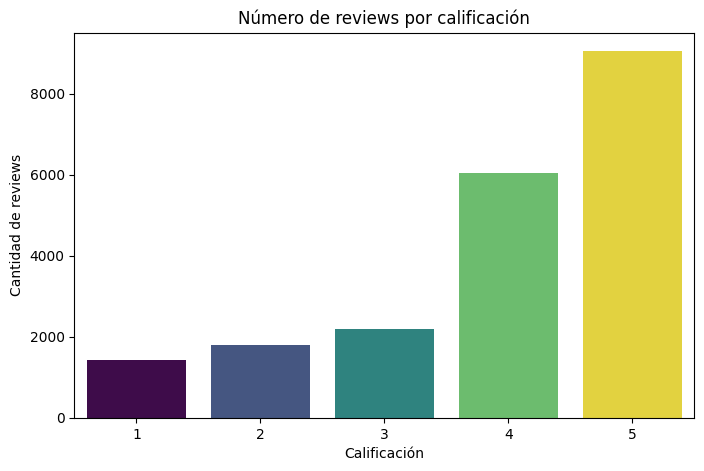

In [14]:
rating_counts = df['Rating'].value_counts().sort_index()

plt.figure(figsize=(8,5))
sns.barplot(x=rating_counts.index, y=rating_counts.values, hue=rating_counts.index, legend=False, palette="viridis")
plt.title("Número de reviews por calificación")
plt.xlabel("Calificación")
plt.ylabel("Cantidad de reviews")
plt.show()

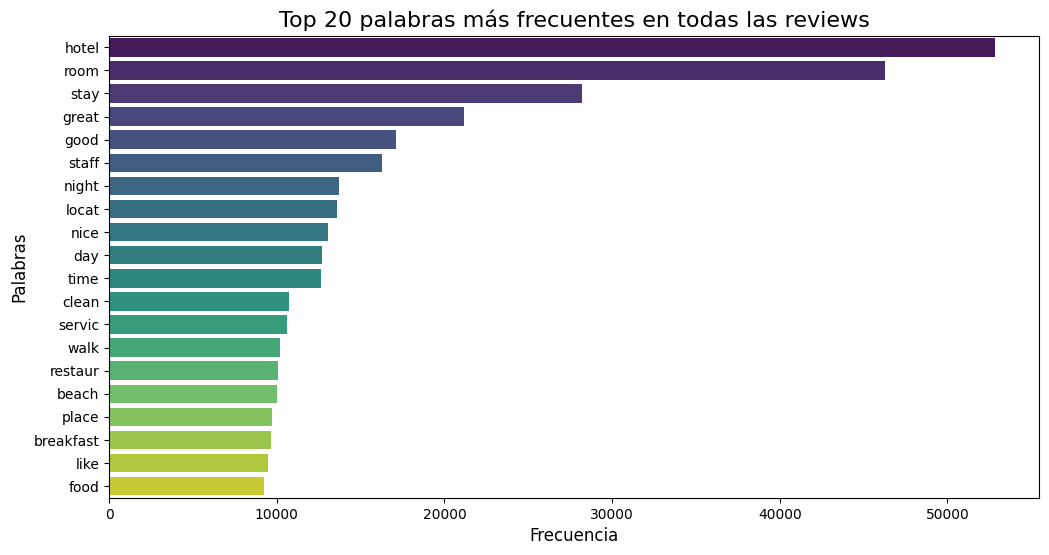

In [15]:
all_words = [word for tokens in df['Stemmed'] for word in tokens]
word_counts = Counter(all_words)

common_words = word_counts.most_common(20)
words, counts = zip(*common_words)

plt.figure(figsize=(12,6))
sns.barplot(x=list(counts), y=list(words), hue=list(words), legend=False, palette="viridis")
plt.title("Top 20 palabras más frecuentes en todas las reviews", fontsize=16)
plt.xlabel("Frecuencia", fontsize=12)
plt.ylabel("Palabras", fontsize=12)
plt.show()

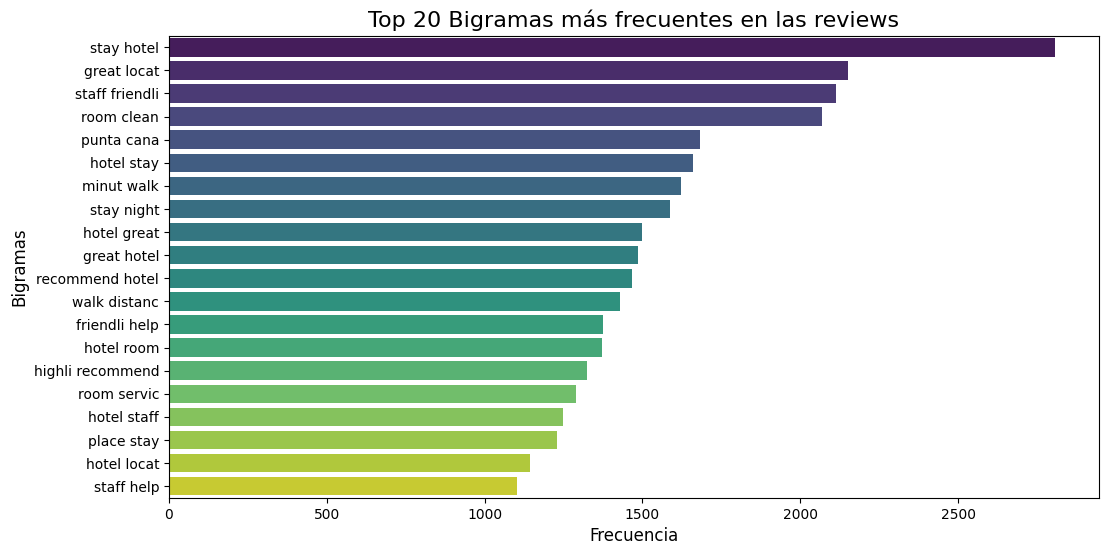

In [16]:
# Bigramas con lemmatization
vectorizer = CountVectorizer(ngram_range=(2,2))
X = vectorizer.fit_transform(df['Stemmed'].apply(lambda x: " ".join(x)))

bigrams = X.sum(axis=0)
bigram_counts = [(word, bigrams[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
bigram_counts = sorted(bigram_counts, key=lambda x: x[1], reverse=True)

top_bigrams = bigram_counts[:20]
bigrams_words, bigrams_values = zip(*top_bigrams)

plt.figure(figsize=(12,6))
sns.barplot(x=list(bigrams_values), y=list(bigrams_words), hue=list(bigrams_words), legend=False, palette="viridis")
plt.title("Top 20 Bigramas más frecuentes en las reviews", fontsize=16)
plt.xlabel("Frecuencia", fontsize=12)
plt.ylabel("Bigramas", fontsize=12)
plt.show()

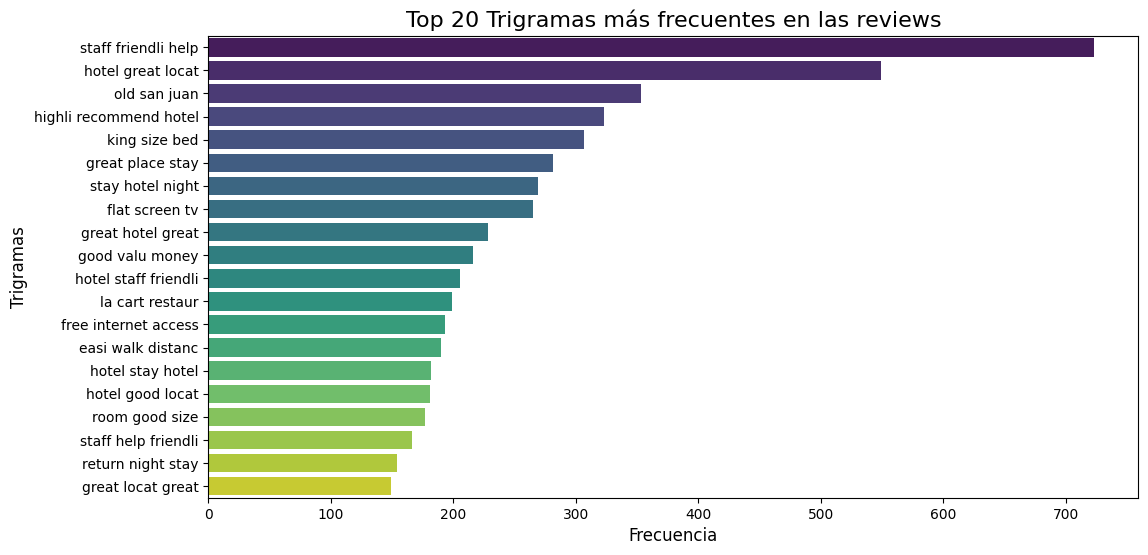

In [17]:
# Trigramas con lemmatization
vectorizer = CountVectorizer(ngram_range=(3,3))
X = vectorizer.fit_transform(df['Stemmed'].apply(lambda x: " ".join(x)))

trigrams = X.sum(axis=0)
trigram_counts = [(word, trigrams[0, idx]) for word, idx in vectorizer.vocabulary_.items()]
trigram_counts = sorted(trigram_counts, key=lambda x: x[1], reverse=True)

top_trigrams = trigram_counts[:20]
trigrams_words, trigrams_values = zip(*top_trigrams)

plt.figure(figsize=(12,6))
sns.barplot(x=list(trigrams_values), y=list(trigrams_words), hue=list(trigrams_words), legend=False, palette="viridis")
plt.title("Top 20 Trigramas más frecuentes en las reviews", fontsize=16)
plt.xlabel("Frecuencia", fontsize=12)
plt.ylabel("Trigramas", fontsize=12)
plt.show()

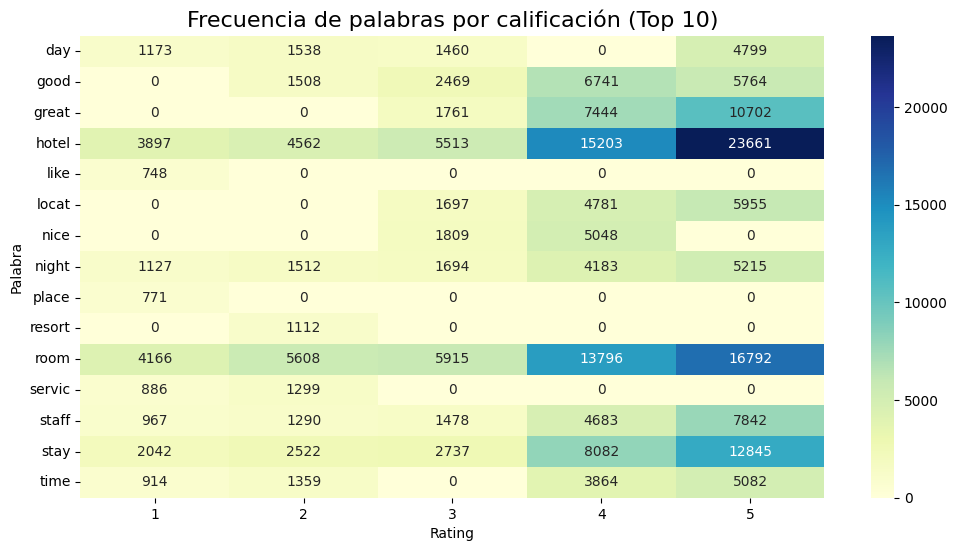

In [18]:
top_n = 10
ratings = sorted(df['Rating'].unique())
data = []

for r in ratings:
    words_r = [word for tokens in df[df['Rating']==r]['Stemmed'] for word in tokens]
    for word, count in Counter(words_r).most_common(top_n):
        data.append({'Rating': r, 'Word': word, 'Count': count})

df_words = pd.DataFrame(data)

heat_data = df_words.pivot_table(index='Word', columns='Rating', values='Count', fill_value=0)
heat_data_int = heat_data.astype(int)

plt.figure(figsize=(12,6))
sns.heatmap(heat_data_int, annot=True, fmt="d", cmap="YlGnBu")
plt.title(f"Frecuencia de palabras por calificación (Top {top_n})", fontsize=16)
plt.xlabel("Rating")
plt.ylabel("Palabra")
plt.show()

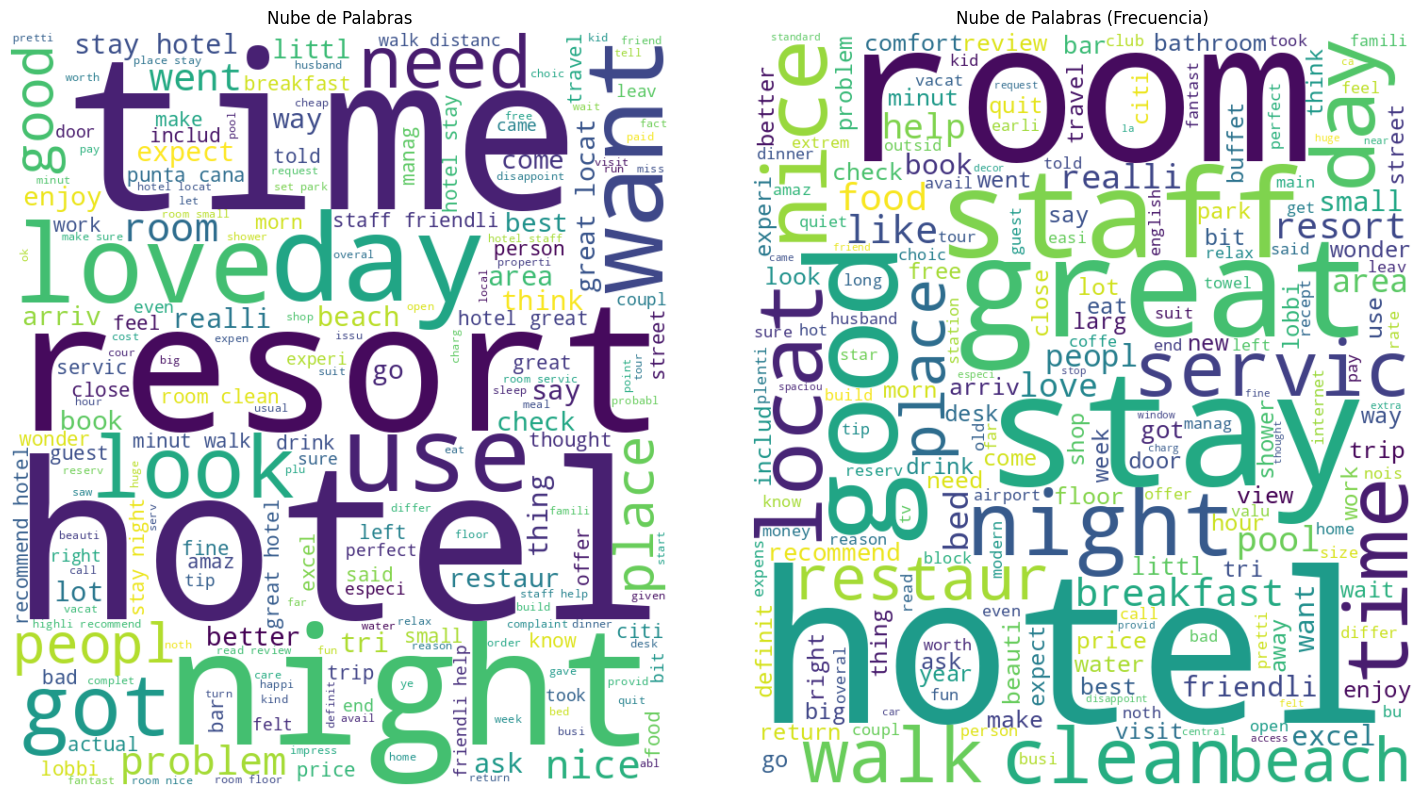

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(15, 8))

text = " ".join(all_words)
wc = WordCloud(width=700, height=800, background_color='white', random_state=42).generate(text)
wc2 = WordCloud(width=700, height=800, background_color='white', random_state=42).generate_from_frequencies(word_counts)

axes[0].imshow(wc, interpolation='bilinear')
axes[0].axis('off')
axes[0].set_title('Nube de Palabras')

axes[1].imshow(wc2, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Nube de Palabras (Frecuencia)')

plt.tight_layout()
plt.show()

### **CLUSTERING:**

Antes de pasar a los modelos, conviene ver si los textos ya muestran alguna estructura con representaciones más simples. A continuación, se comparan BoW y TF-IDF con KMeans y con varias métricas de calidad para decidir cuántos grupos podrían tener sentido.

#### Bag of Words (BoW)

In [20]:
corpus = df['Stemmed'].apply(lambda x: " ".join(x)).tolist()
vectorizer = CountVectorizer(min_df=10, max_features=5000)
X = vectorizer.fit_transform(corpus)

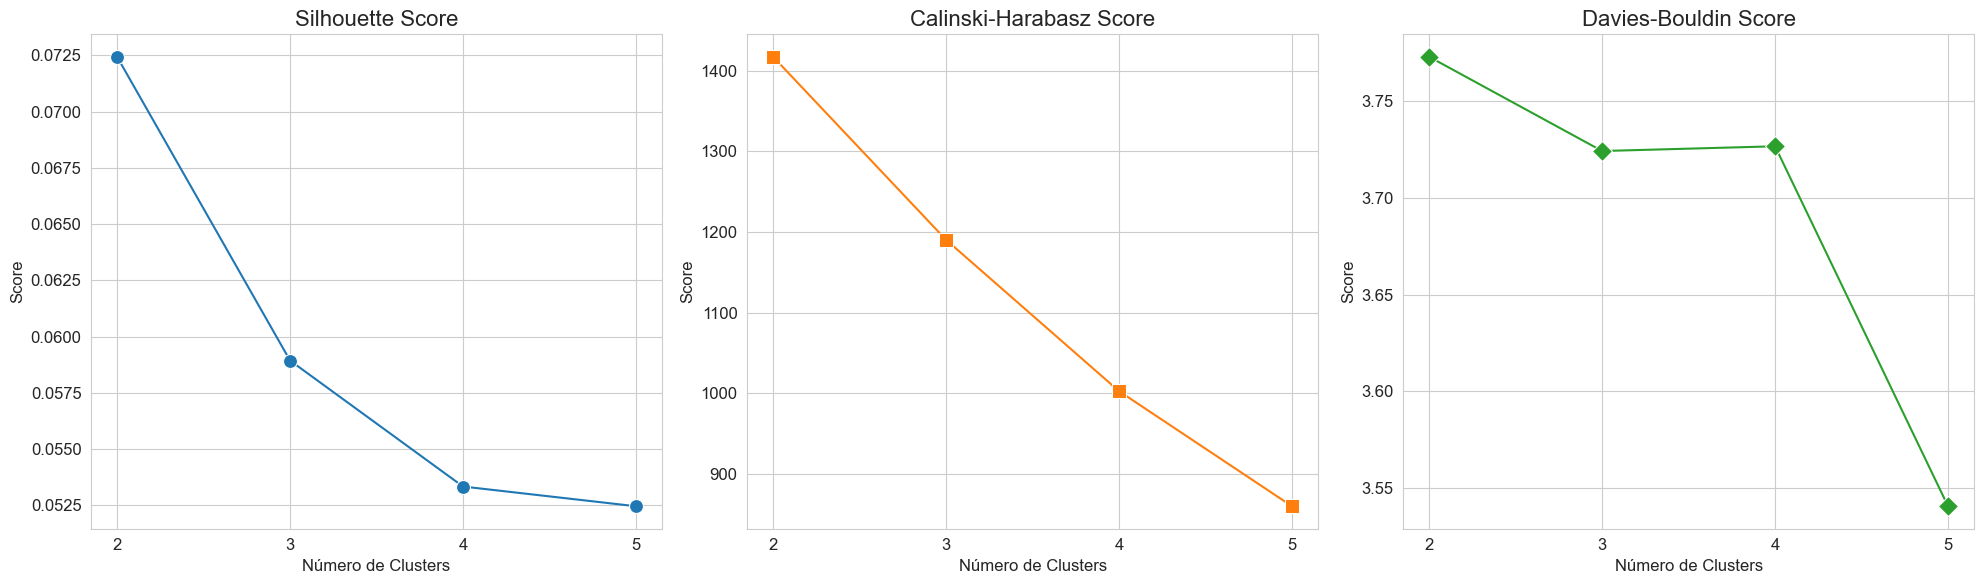

In [21]:
svd = TruncatedSVD(n_components=100, random_state=42)
X_dense = svd.fit_transform(X)
X_dense = Normalizer().fit_transform(X_dense)

silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []
k_values = range(2, 6)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_dense)
    silhouette_scores.append(silhouette_score(X_dense, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_dense, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_dense, labels))

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Silhouette
sns.lineplot(x=k_values, y=silhouette_scores, marker='o', markersize=10, color="#1f77b4", ax=axes[0])
axes[0].set_title("Silhouette Score", fontsize=16)
axes[0].set_xlabel("Número de Clusters")
axes[0].set_ylabel("Score")
axes[0].grid(True)
axes[0].set_xticks(k_values)

# Calinski-Harabasz
sns.lineplot(x=k_values, y=calinski_harabasz_scores, marker='s', markersize=10, color="#ff7f0e", ax=axes[1])
axes[1].set_title("Calinski-Harabasz Score", fontsize=16)
axes[1].set_xlabel("Número de Clusters")
axes[1].set_ylabel("Score")
axes[1].grid(True)
axes[1].set_xticks(k_values)

# Davies-Bouldin
sns.lineplot(x=k_values, y=davies_bouldin_scores, marker='D', markersize=10, color="#2ca02c", ax=axes[2])
axes[2].set_title("Davies-Bouldin Score", fontsize=16)
axes[2].set_xlabel("Número de Clusters")
axes[2].set_ylabel("Score")
axes[2].grid(True)
axes[2].set_xticks(k_values)

plt.tight_layout()
plt.show()

In [22]:
print(f"Varianza total explicada: {svd.explained_variance_ratio_.sum():.2%}")

Varianza total explicada: 51.25%


In [23]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)
df['cluster_bow_2'] = kmeans.labels_

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)
df['cluster_bow_5'] = kmeans.labels_

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

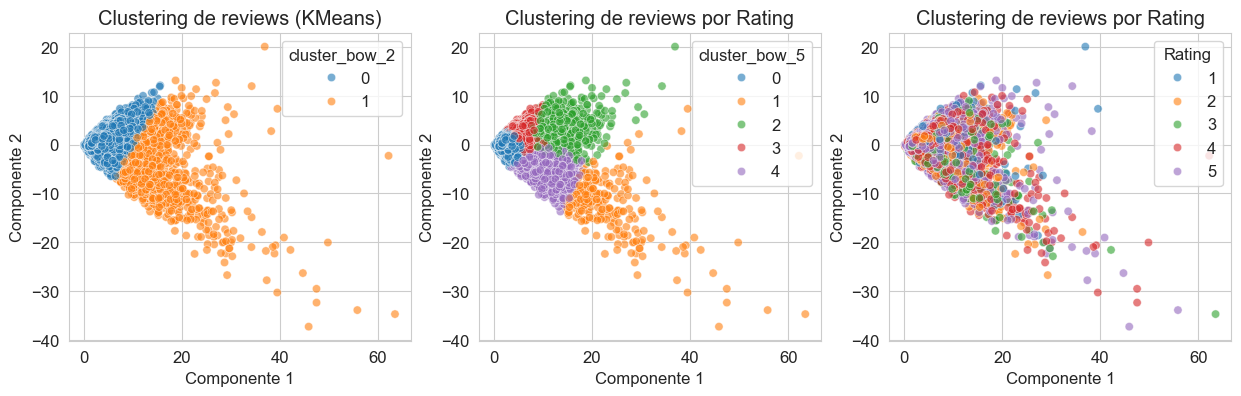

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=df['cluster_bow_2'], palette='tab10', alpha=0.6, ax=axes[0])
axes[0].set_title("Clustering de reviews (KMeans)")
axes[0].set_xlabel("Componente 1")
axes[0].set_ylabel("Componente 2")

sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=df['cluster_bow_5'], palette='tab10', alpha=0.6, ax=axes[1])
axes[1].set_title("Clustering de reviews por Rating")
axes[1].set_xlabel("Componente 1")
axes[1].set_ylabel("Componente 2")  

sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=df['Rating'], palette='tab10', alpha=0.6, ax=axes[2])
axes[2].set_title("Clustering de reviews por Rating")
axes[2].set_xlabel("Componente 1")
axes[2].set_ylabel("Componente 2")

plt.show()


#### Term Frequency – Inverse Document Frequency (TF-IDF)

In [25]:
corpus = df['Stemmed'].apply(lambda x: " ".join(x)).tolist()
vectorizer = TfidfVectorizer(
    min_df=5, 
    max_df=0.7, 
    ngram_range=(1, 2)
)
X = vectorizer.fit_transform(corpus)

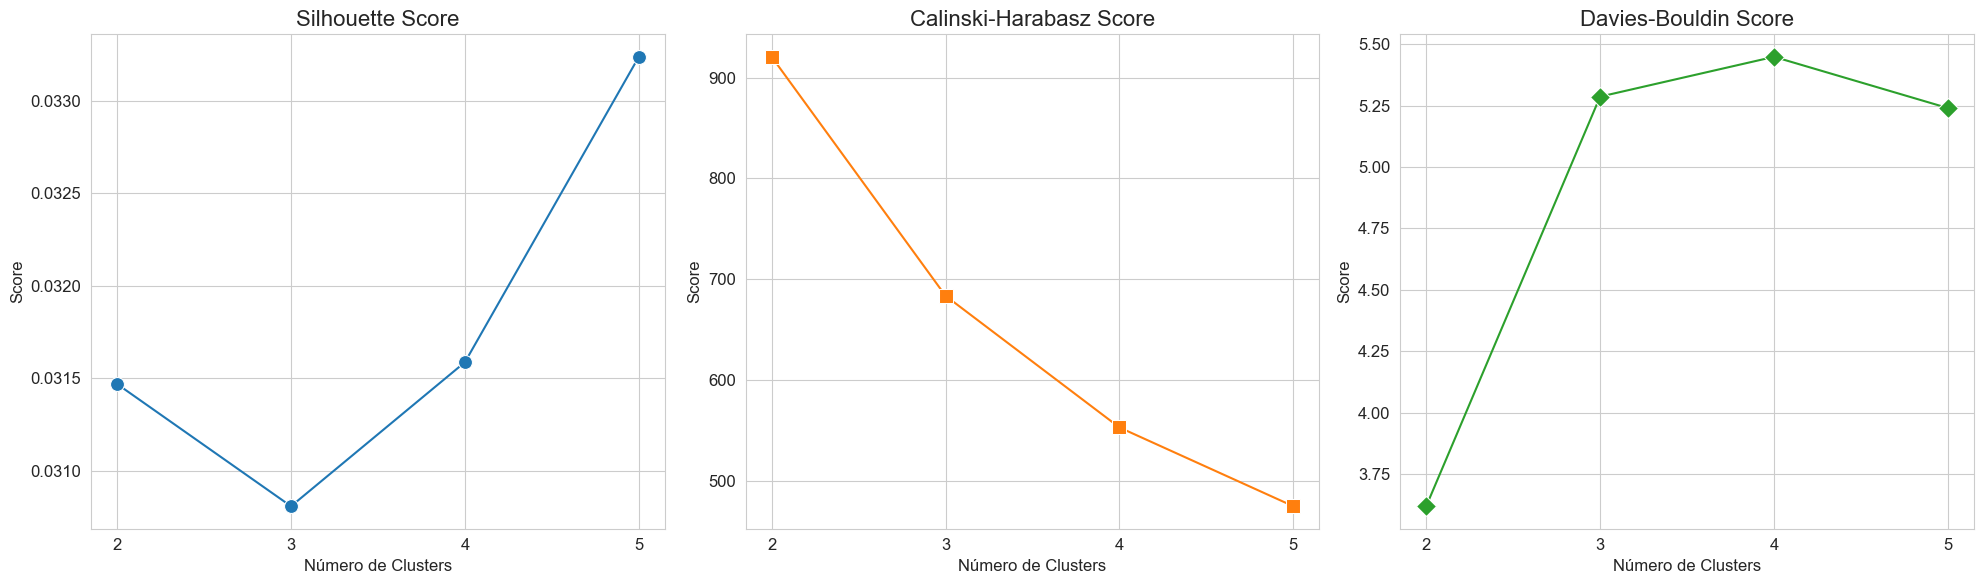

In [26]:
svd = TruncatedSVD(n_components=100, random_state=42)
X_dense = svd.fit_transform(X)
X_dense = Normalizer().fit_transform(X_dense)

silhouette_scores = []
calinski_harabasz_scores = []
davies_bouldin_scores = []
k_values = range(2, 6)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_dense)
    silhouette_scores.append(silhouette_score(X_dense, labels))
    calinski_harabasz_scores.append(calinski_harabasz_score(X_dense, labels))
    davies_bouldin_scores.append(davies_bouldin_score(X_dense, labels))

sns.set_style("whitegrid")
plt.rcParams.update({'font.size': 12})

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Silhouette
sns.lineplot(x=k_values, y=silhouette_scores, marker='o', markersize=10, color="#1f77b4", ax=axes[0])
axes[0].set_title("Silhouette Score", fontsize=16)
axes[0].set_xlabel("Número de Clusters")
axes[0].set_ylabel("Score")
axes[0].grid(True)
axes[0].set_xticks(k_values)

# Calinski-Harabasz
sns.lineplot(x=k_values, y=calinski_harabasz_scores, marker='s', markersize=10, color="#ff7f0e", ax=axes[1])
axes[1].set_title("Calinski-Harabasz Score", fontsize=16)
axes[1].set_xlabel("Número de Clusters")
axes[1].set_ylabel("Score")
axes[1].grid(True)
axes[1].set_xticks(k_values)

# Davies-Bouldin
sns.lineplot(x=k_values, y=davies_bouldin_scores, marker='D', markersize=10, color="#2ca02c", ax=axes[2])
axes[2].set_title("Davies-Bouldin Score", fontsize=16)
axes[2].set_xlabel("Número de Clusters")
axes[2].set_ylabel("Score")
axes[2].grid(True)
axes[2].set_xticks(k_values)

plt.tight_layout()
plt.show()

In [27]:
print(f"Varianza total explicada: {svd.explained_variance_ratio_.sum():.2%}")

Varianza total explicada: 8.65%


In [28]:
k = 2
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)
df['cluster_tfidf_2'] = kmeans.labels_

k = 5
kmeans = KMeans(n_clusters=k, random_state=42)
kmeans.fit(X)
df['cluster_tfidf_5'] = kmeans.labels_

svd = TruncatedSVD(n_components=2, random_state=42)
X_2d = svd.fit_transform(X)

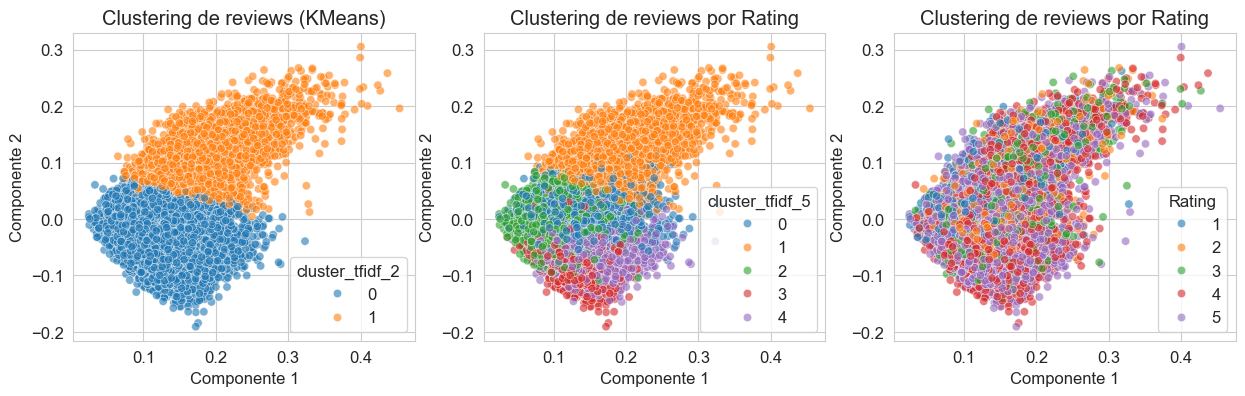

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15,4))

sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=df['cluster_tfidf_2'], palette='tab10', alpha=0.6, ax=axes[0])
axes[0].set_title("Clustering de reviews (KMeans)")
axes[0].set_xlabel("Componente 1")
axes[0].set_ylabel("Componente 2")

sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=df['cluster_tfidf_5'], palette='tab10', alpha=0.6, ax=axes[1])
axes[1].set_title("Clustering de reviews por Rating")
axes[1].set_xlabel("Componente 1")
axes[1].set_ylabel("Componente 2")  

sns.scatterplot(x=X_2d[:,0], y=X_2d[:,1], hue=df['Rating'], palette='tab10', alpha=0.6, ax=axes[2])
axes[2].set_title("Clustering de reviews por Rating")
axes[2].set_xlabel("Componente 1")
axes[2].set_ylabel("Componente 2")

plt.show()

Conclusión: la semántica del texto no siempre se alinea con el Rating.

### **CLASIFICACIÓN DEL SENTIMIENTO:**

Aquí pasamos de explorar el texto a predecir sentimiento. La idea es simple: convertir el rating en una etiqueta binaria y comparar varias representaciones para ver cuál separa mejor reseñas positivas y negativas.

In [30]:
# 0 = Negativo (1 y 2 estrellas), 1 = Positivo (3, 4 y 5 estrellas)
df['label'] = df['Rating'].apply(lambda x: 1 if x >= 3 else 0)

In [31]:
bow_vect = CountVectorizer(min_df=5, max_df=0.8, ngram_range=(1,1))
X_bow = bow_vect.fit_transform(corpus)

tfidf_vect = TfidfVectorizer(min_df=5, max_df=0.8)
X_tfidf = tfidf_vect.fit_transform(corpus)

sentences = [doc.split() for doc in corpus]
w2v_model = Word2Vec(sentences, vector_size=100, window=5, min_count=5, workers=4)

def get_avg_vector(words, model, num_features):
    feature_vec = np.zeros((num_features,), dtype="float32")
    n_words = 0
    for word in words:
        if word in model.wv:
            n_words += 1
            feature_vec = np.add(feature_vec, model.wv[word])
    if n_words > 0:
        feature_vec = np.divide(feature_vec, n_words)
    return feature_vec

X_w2v = np.array([get_avg_vector(s, w2v_model, 100) for s in sentences])

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [32]:
# Balanceo de clases
df_pos = df[df['label'] == 1]
df_neg = df[df['label'] == 0]

df_pos_downsampled = resample(
    df_pos,
    replace=False,
    n_samples=len(df_neg),
    random_state=42
)

df_balanced = pd.concat([df_pos_downsampled, df_neg]).sample(frac=1, random_state=42)

balanced_pos = df.index.get_indexer(df_balanced.index)
y_bal = df_balanced['label'].to_numpy()

X_bow_bal = X_bow[balanced_pos]
X_tfidf_bal = X_tfidf[balanced_pos]
X_w2v_bal = X_w2v[balanced_pos]

def plot_confusion_matrix(y_true, y_pred, ax, title):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

#### LOGISTIC REGRESSION

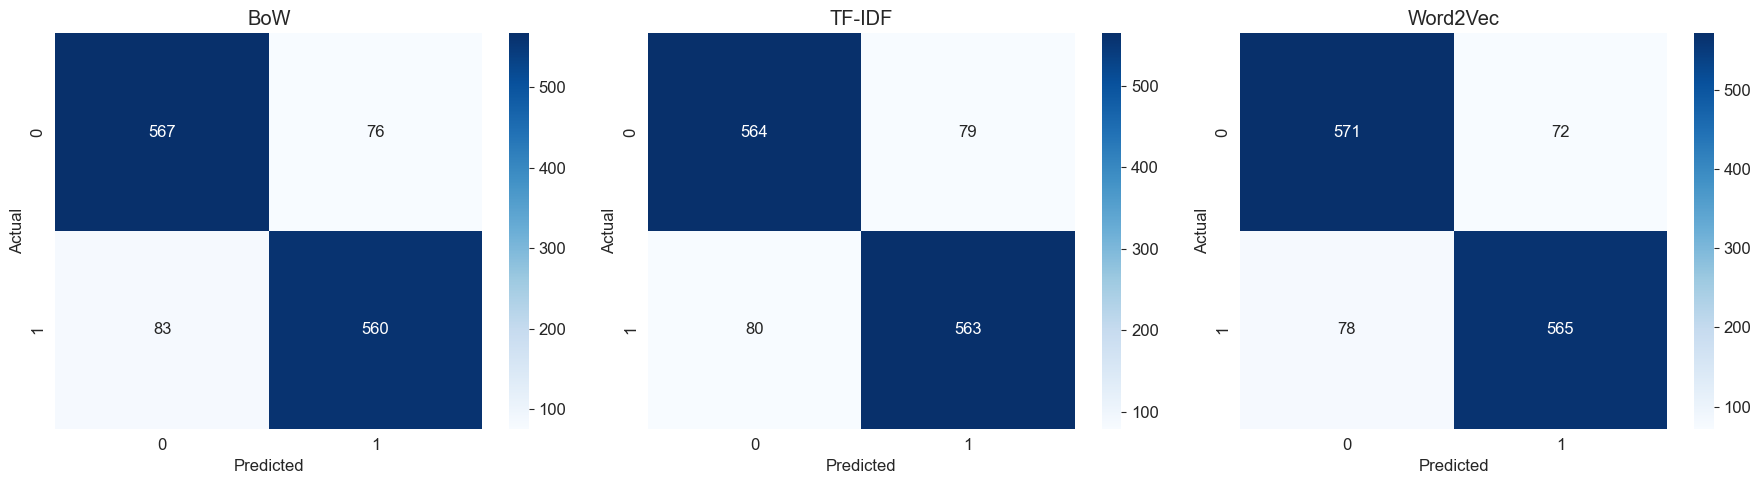

In [33]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def evaluar_logreg(X_data, y_data, ax, title):
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
    )

    scaler = StandardScaler(with_mean=False) if hasattr(X_train, "toarray") else StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = LogisticRegression(max_iter=1000, random_state=42)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    plot_confusion_matrix(y_test, y_pred, ax, title)

evaluar_logreg(X_bow_bal, y_bal, axes[0], "BoW")
evaluar_logreg(X_tfidf_bal, y_bal, axes[1], "TF-IDF")
evaluar_logreg(X_w2v_bal, y_bal, axes[2], "Word2Vec")

plt.tight_layout()
plt.show()

#### RANDOM FOREST

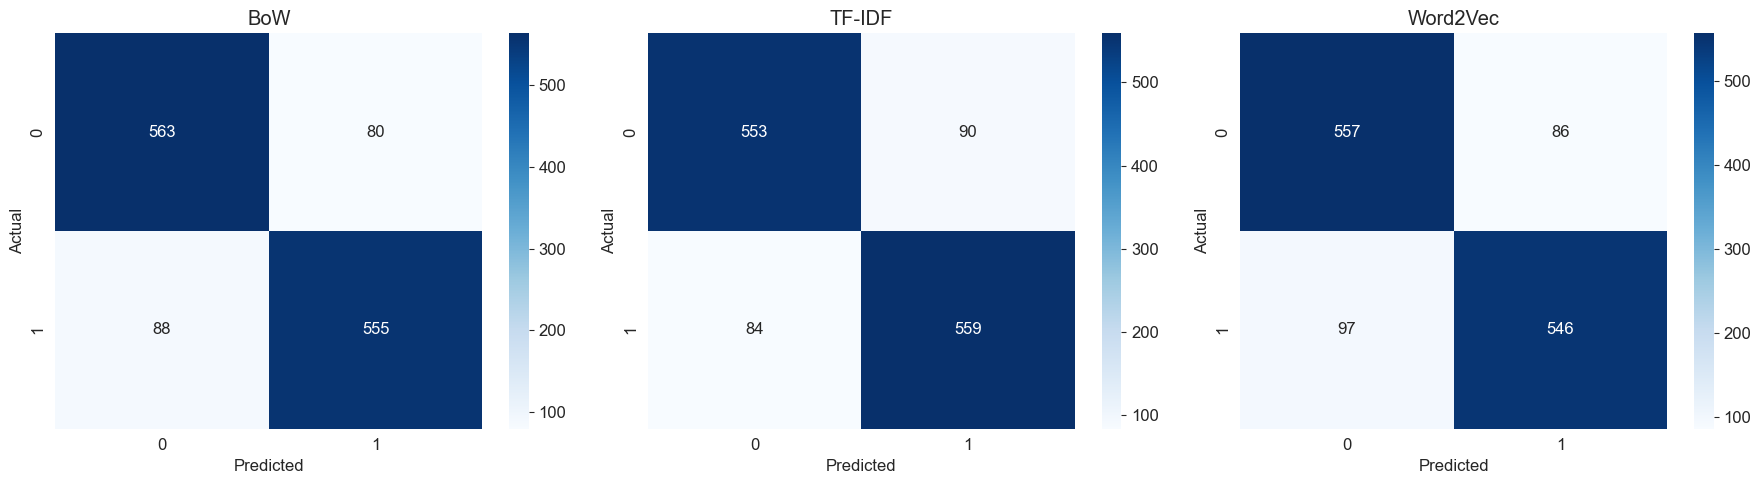

In [34]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def evaluar_rf(X_data, y_data, ax, title):
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
    )

    scaler = StandardScaler(with_mean=False) if hasattr(X_train, "toarray") else StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = RandomForestClassifier(n_estimators=100, random_state=42)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    plot_confusion_matrix(y_test, y_pred, ax, title)

evaluar_rf(X_bow_bal, y_bal, axes[0], "BoW")
evaluar_rf(X_tfidf_bal, y_bal, axes[1], "TF-IDF")
evaluar_rf(X_w2v_bal, y_bal, axes[2], "Word2Vec")

plt.tight_layout()
plt.show()

#### SVM

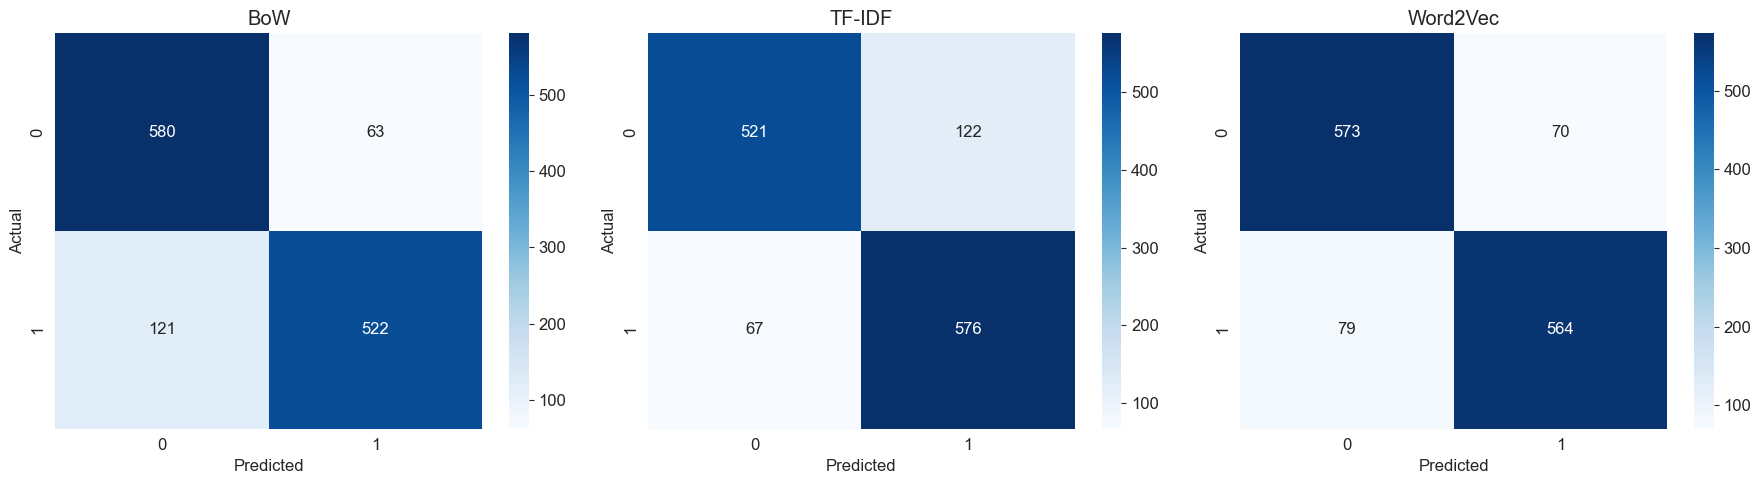

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def evaluar_svm(X_data, y_data, ax, title):
    X_train, X_test, y_train, y_test = train_test_split(
        X_data, y_data, test_size=0.2, random_state=42, stratify=y_data
    )
    
    scaler = StandardScaler(with_mean=False) if hasattr(X_train, "toarray") else StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    clf = SVC(max_iter=-1, random_state=42)
    clf.fit(X_train_scaled, y_train)
    y_pred = clf.predict(X_test_scaled)
    plot_confusion_matrix(y_test, y_pred, ax, title)

evaluar_svm(X_bow_bal, y_bal, axes[0], "BoW")
evaluar_svm(X_tfidf_bal, y_bal, axes[1], "TF-IDF")
evaluar_svm(X_w2v_bal, y_bal, axes[2], "Word2Vec")

plt.tight_layout()
plt.show()

### Conclusiones 

Con BoW, TF-IDF y Word2Vec se han visto tres formas distintas de representar el lenguaje. Las dos primeras son más directas y dependen mucho de las palabras exactas; Word2Vec captura algo más de relación entre términos, aunque sigue sin entender el contexto completo de una frase. En el siguiente notebook (4-2) seguiremos con este mismo dataset, pero dando el salto a BERT para trabajar con embeddings contextuales, motor de búsqueda semántica y una representación más rica del significado del texto.